In [ ]:
# Cell 1: Import Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Cell 2.1: Extract the ZIP Archive (Handling Double ZIP)
import zipfile
import os

zip_filename = 'Project9_smart-city-traffic-patterns.zip'
extraction_folder = 'extracted_traffic_data'

if os.path.exists(zip_filename):
    print(f"Extracting first layer: {zip_filename}...")
    os.makedirs(extraction_folder, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extraction_folder)

    # Check for nested ZIP
    nested_zip = os.path.join(extraction_folder, 'Project9_smart-city-traffic-patterns', 'Project9_smart-city-traffic-patterns.zip')
    if os.path.exists(nested_zip):
        print(f"Found nested archive: {nested_zip}. Extracting second layer...")
        with zipfile.ZipFile(nested_zip, 'r') as zip_ref:
            zip_ref.extractall(extraction_folder)
        print("Double extraction complete.")
    else:
        print("Extraction complete.")
else:
    print(f"ERROR: '{zip_filename}' not found.")

Extracting first layer: Project9_smart-city-traffic-patterns.zip...
Found nested archive: extracted_traffic_data/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns.zip. Extracting second layer...
Double extraction complete.


In [ ]:
# Cell 2.3: Fuzzy Search for Train and Test CSVs
import os
import pandas as pd

train_path = None
test_path = None

print("Initiating fuzzy search for training and testing datasets...")

# Walk through all directories and sub-directories in the environment
for root, dirs, files in os.walk('.'):
    for file in files:
        # Check if the file is a CSV
        if file.endswith('.csv'):
            # If 'train' is in the filename (case-insensitive), save the path
            if 'train' in file.lower() and train_path is None:
                train_path = os.path.join(root, file)

            # If 'test' is in the filename (case-insensitive), save the path
            elif 'test' in file.lower() and test_path is None:
                test_path = os.path.join(root, file)

# Check if the fuzzy search was successful
if train_path and test_path:
    print(f"SUCCESS: Found Training Data at: {train_path}")
    print(f"SUCCESS: Found Testing Data at: {test_path}\n")

    # Load the datasets into Pandas DataFrames
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print("Data loaded successfully.")
    print(f"Training data shape: {train_df.shape}")
    print(f"Testing data shape: {test_df.shape}")
    display(train_df.head())

else:
    print("ERROR: Still cannot find the CSV files.")
    print("Let's investigate what is actually inside your environment.")
    print("-" * 40)
    print("List of all files currently in your workspace:")

    # Fallback: Print all files so you can see exactly what is going on
    for root, dirs, files in os.walk('.'):
        for file in files:
            # Ignoring hidden folders like .config or .git to keep the list clean
            if not root.startswith('./.'):
                print(os.path.join(root, file))

Initiating fuzzy search for training and testing datasets...
SUCCESS: Found Training Data at: ./extracted_traffic_data/smart-city-traffic-patterns/train_aWnotuB.csv
SUCCESS: Found Testing Data at: ./extracted_traffic_data/smart-city-traffic-patterns/datasets_8494_11879_test_BdBKkAj.csv

Data loaded successfully.
Training data shape: (48120, 4)
Testing data shape: (11808, 3)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
# Cell 3: Feature Extraction from DateTime
def extract_time_features(df):
    """Extracts chronological features from the DateTime column."""
    df = df.copy()
    df['DateTime'] = pd.to_datetime(df['DateTime'])

    # Extract chronological components
    df['Year'] = df['DateTime'].dt.year
    df['Month'] = df['DateTime'].dt.month
    df['Day'] = df['DateTime'].dt.day
    df['Hour'] = df['DateTime'].dt.hour
    df['DayOfWeek'] = df['DateTime'].dt.dayofweek

    # Create a binary feature for weekends (Saturday=5, Sunday=6)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    return df

print("Applying feature engineering...")
train_features = extract_time_features(train_df)
test_features = extract_time_features(test_df)

# Define features (X) and target (y)
# ID is dropped as it is an arbitrary identifier; DateTime is dropped as it is now parsed
X = train_features.drop(columns=['ID', 'DateTime', 'Vehicles'])
y = train_features['Vehicles']

# Prepare testing data
X_submission = test_features.drop(columns=['ID', 'DateTime'])

print("Feature engineering complete. Available features:")
print(X.columns.tolist())

Applying feature engineering...
Feature engineering complete. Available features:
['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'IsWeekend']


In [ ]:
# Cell 4: Train-Validation Split and Model Fitting
print("Splitting data and training XGBoost Regressor...")

# Chronological split is generally preferred for time-series, but we will use
# standard train_test_split here assuming the features capture the temporal variations
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model
# Parameters are tuned for general tabular regression tasks
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Generate validation predictions
y_val_pred = model.predict(X_val)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("-" * 40)
print("VALIDATION METRICS")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")
print("-" * 40)

Splitting data and training XGBoost Regressor...
----------------------------------------
VALIDATION METRICS
Root Mean Squared Error (RMSE): 4.6015
R-squared Score: 0.9480
----------------------------------------


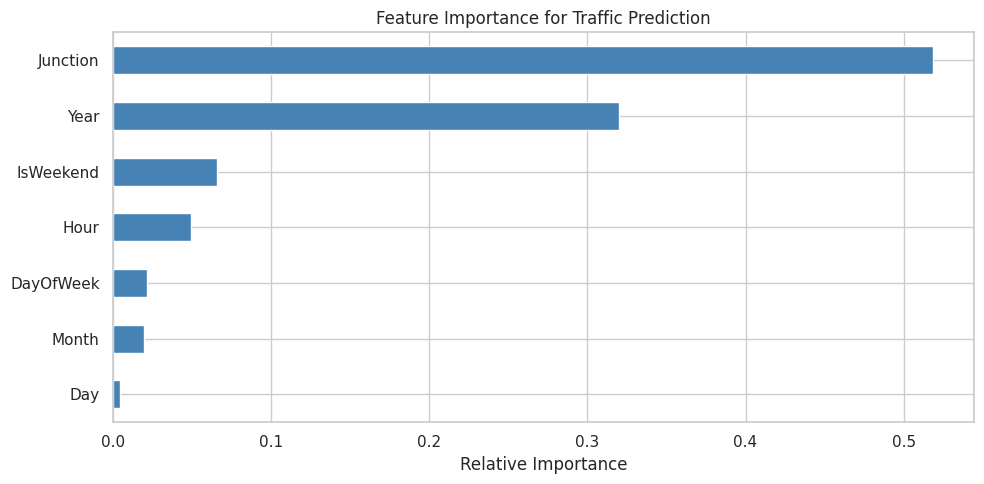

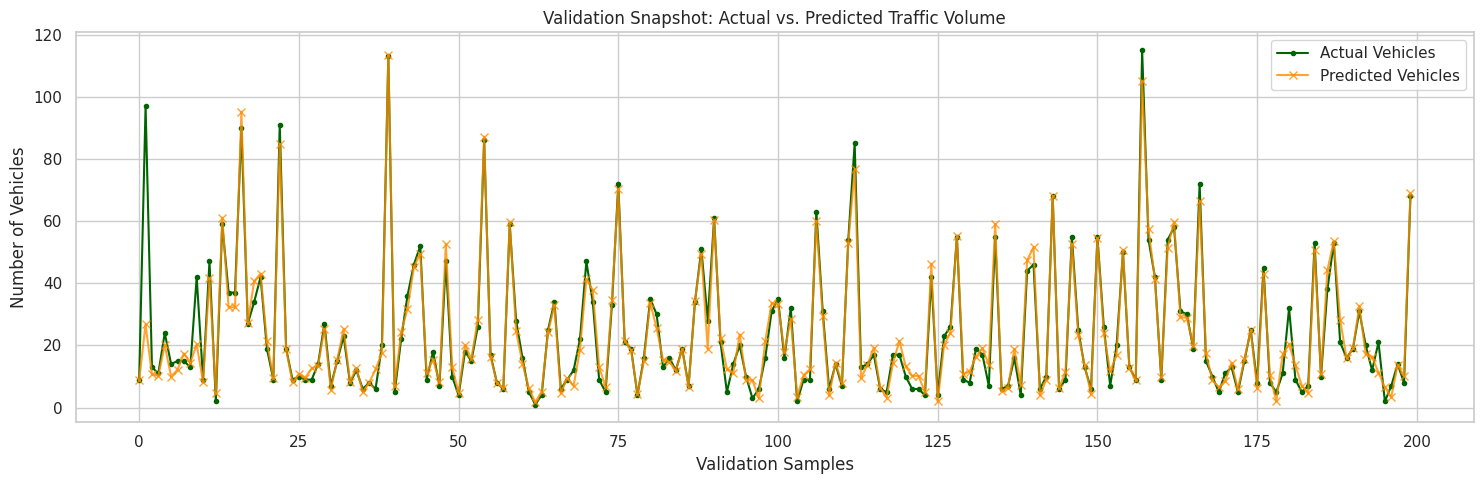

In [ ]:
# Cell 5: Model Evaluation Visualizations

# 1. Feature Importance Plot
importance = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 5))
importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance for Traffic Prediction')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

# 2. Actual vs. Predicted Traffic (Snapshot of 200 data points)
plt.figure(figsize=(15, 5))
plt.plot(y_val.values[:200], label='Actual Vehicles', color='darkgreen', marker='.')
plt.plot(y_val_pred[:200], label='Predicted Vehicles', color='darkorange', alpha=0.8, marker='x')
plt.title('Validation Snapshot: Actual vs. Predicted Traffic Volume')
plt.xlabel('Validation Samples')
plt.ylabel('Number of Vehicles')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Generate Final Predictions and Submission File
print("Generating predictions for the test dataset...")

# Predict on the unseen test data
test_predictions = model.predict(X_submission)

# Ensure no negative vehicle counts are predicted
test_predictions = np.maximum(0, test_predictions)

# Create the submission dataframe
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'Vehicles': np.round(test_predictions).astype(int) # Vehicles must be whole numbers
})

# Save to CSV
submission_filename = 'traffic_prediction_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file successfully saved as: {submission_filename}")
display(submission_df.head())

Generating predictions for the test dataset...
Submission file successfully saved as: traffic_prediction_submission.csv


,ID,Vehicles
0,20170701001,62
1,20170701011,54
2,20170701021,42
3,20170701031,37
4,20170701041,30


Generating time-based traffic pattern visualizations...


/tmp/ipykernel_1542/1882590324.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_traffic, x='DayName', y='Vehicles', palette='viridis', ax=axes[1])


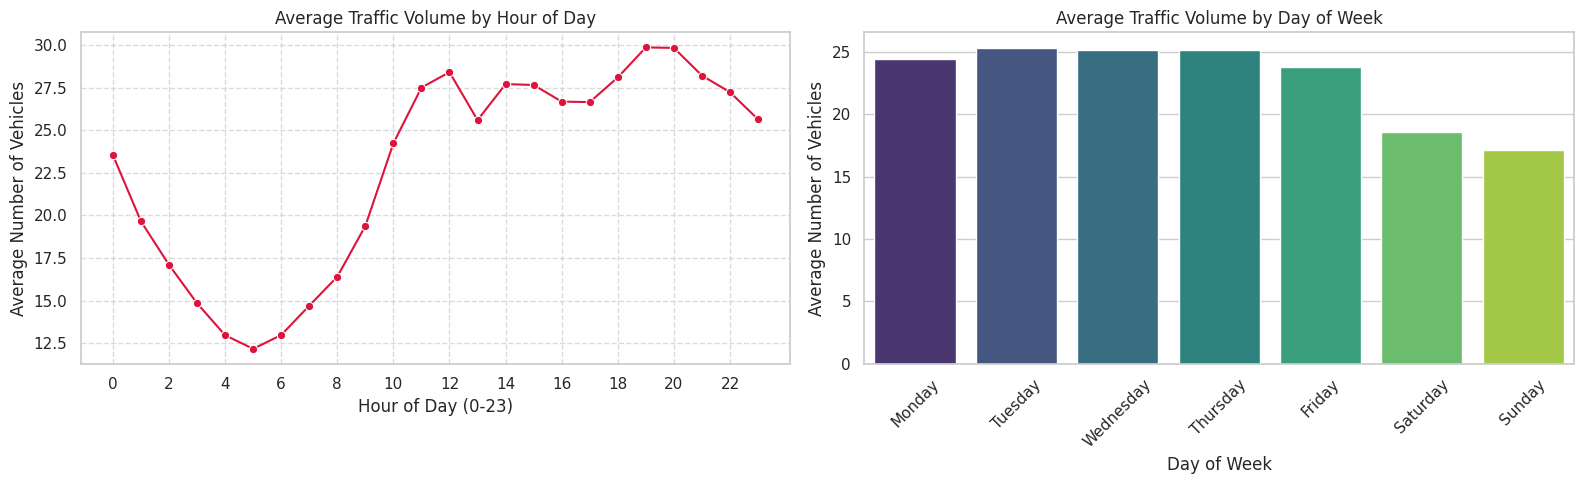

In [ ]:
# Cell 7: Hourly and Weekly Traffic Patterns
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating time-based traffic pattern visualizations...")

# Set up a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Average Traffic by Hour of Day
hourly_traffic = train_features.groupby('Hour')['Vehicles'].mean().reset_index()
sns.lineplot(data=hourly_traffic, x='Hour', y='Vehicles', marker='o', color='crimson', ax=axes[0])
axes[0].set_title('Average Traffic Volume by Hour of Day')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Average Number of Vehicles')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Average Traffic by Day of Week
# Map day indices to actual names for better readability
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekly_traffic = train_features.groupby('DayOfWeek')['Vehicles'].mean().reset_index()
weekly_traffic['DayName'] = weekly_traffic['DayOfWeek'].map(day_mapping)

sns.barplot(data=weekly_traffic, x='DayName', y='Vehicles', palette='viridis', ax=axes[1])
axes[1].set_title('Average Traffic Volume by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Number of Vehicles')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Generating correlation heatmap...


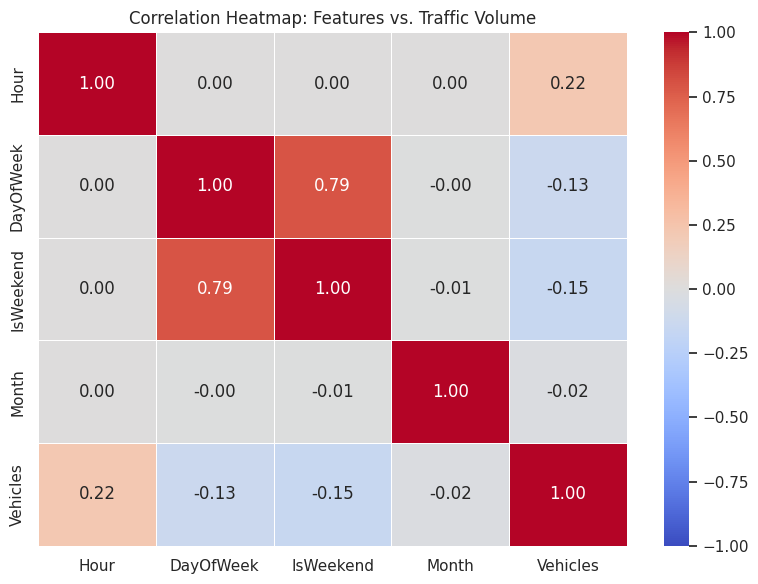

In [ ]:
# Cell 8: Feature Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating correlation heatmap...")

# Select the numerical columns for correlation
cols_for_corr = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month', 'Vehicles']
corr_matrix = train_features[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Features vs. Traffic Volume')
plt.tight_layout()
plt.show()

Generating prediction error scatter plot...


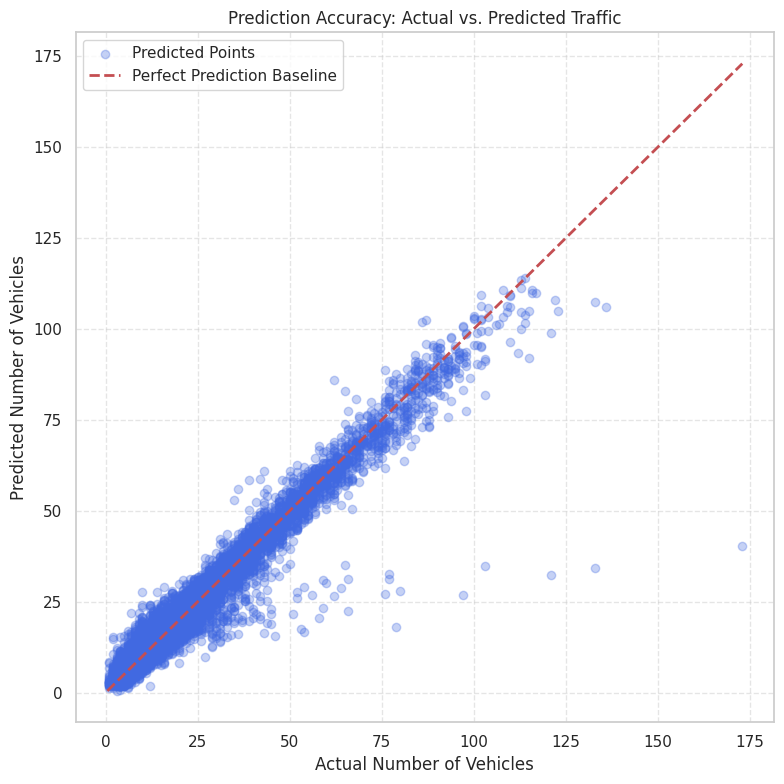

In [ ]:
# Cell 9: Actual vs. Predicted Scatter Plot
import matplotlib.pyplot as plt
import numpy as np

print("Generating prediction error scatter plot...")

plt.figure(figsize=(8, 8))

# Scatter plot of Actual vs Predicted values
plt.scatter(y_val, y_val_pred, alpha=0.3, color='royalblue', label='Predicted Points')

# Draw the perfect prediction baseline (y = x)
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction Baseline')

plt.title('Prediction Accuracy: Actual vs. Predicted Traffic')
plt.xlabel('Actual Number of Vehicles')
plt.ylabel('Predicted Number of Vehicles')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()